# Week 3 · Notebook 3 — The Sequence Agent (LSTM)
### Multi-Agent Forecasting Project

**Name:Snehil Chatterjee**  
**Date: 30/06/26**  

---

So far every agent has used *hand-engineered* features (lags, RSI, VIX...). The fourth agent is different: an **LSTM** (Long Short-Term Memory) neural network that reads a raw **sequence** of the last 30 daily returns and learns its own temporal patterns. This is your introduction to **deep learning with PyTorch**.

An LSTM is a recurrent network with an internal *memory cell* and *gates* that decide what to remember and what to forget as it steps through a sequence. That makes it naturally suited to time series.

**Topics covered:**
1. **Sliding windows** — turning a 1-D series into (X, y) sequence samples
2. A 2-layer **LSTM** in PyTorch
3. **Normalisation done right** — fit the scaler on train only (no leakage)
4. A training loop with **early stopping**
5. Wrapping it all as a `SequenceAgent` with the same `fit` / `predict` interface

> **Tip:** In Colab, set **Runtime → Change runtime type → T4 GPU** to make training fast. The code runs on CPU too, just slower.

In [ ]:
# Run this cell first.
!pip -q install yfinance

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True; plt.rcParams['grid.alpha'] = 0.3
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch', torch.__version__, '| device:', device)

PyTorch 2.11.0+cu128 | device: cuda


In [ ]:
# Load SPY log returns (the LSTM only needs the return series itself).
import yfinance as yf
spy = yf.download('SPY', start='2010-01-01', end='2024-12-31', auto_adjust=True, progress=False)[['Close']]
spy.columns = ['Close']
spy['log_return'] = np.log(spy['Close'] / spy['Close'].shift(1))
spy = spy.dropna()

train_df = spy[spy.index.year <= 2018]
test_df  = spy[spy.index.year == 2019]
print('train:', len(train_df), '| test:', len(test_df))
train_df.head()

train: 2263 | test: 252


,Close,log_return
Date,,
2010-01-05,84.802361,0.002644
2010-01-06,84.862068,0.000704
2010-01-07,85.220306,0.004213
2010-01-08,85.503899,0.003322
2010-01-11,85.623276,0.001395


---
## Section 1 — Sliding Windows

An LSTM predicts the next value from a fixed-length window of previous values. With `window=30`, sample *i* is:

- **X** = returns on days `[i-30, ..., i-1]` (a length-30 sequence)
- **y** = the return on day `i`

We slide this window across the whole series to generate many (X, y) pairs.

### Exercise 1.1 — Implement `make_sequences`

Loop `i` from `window` to `len(series)`. For each `i`, append `series[i-window:i]` to `X` and `series[i]` to `y`. Return them as float32 numpy arrays.

In [ ]:
# YOUR CODE HERE
def make_sequences(series: np.ndarray, window: int):
    """Turn a 1-D array into (X, y) sliding-window samples."""
    X, y = [], []
    for i in range(window, len(series)):
        X.append(series[i-window:i])   # the window of `window` values ending just before i
        y.append(series[i])   # the value at i
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

# Sanity check on a tiny example
demo = np.arange(10.0)
Xd, yd = make_sequences(demo, window=3)
print('X[0] =', Xd[0], '-> y[0] =', yd[0], '   (expect [0,1,2] -> 3)')
print('shapes:', Xd.shape, yd.shape)

X[0] = [0. 1. 2.] -> y[0] = 3.0    (expect [0,1,2] -> 3)
shapes: (7, 3) (7,)


---
## Section 2 — The LSTM Network

We define a small PyTorch module: a 2-layer LSTM (hidden size 64) followed by a linear head that maps the final hidden state to a single number — the predicted return.

The LSTM expects input shaped `(batch, seq_len, input_size)`. Our `input_size` is 1 (a single return per timestep). We take the output at the **last** timestep, `out[:, -1, :]`, and feed it to the linear head.

In [ ]:
# --- EXAMPLE: the network (provided) ---
class LSTMNet(nn.Module):
    def __init__(self, input_size=1, hidden=64, layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden,
                            num_layers=layers, batch_first=True,
                            dropout=dropout if layers > 1 else 0.0)
        self.head = nn.Linear(hidden, 1)

    def forward(self, x):
        out, _ = self.lstm(x)            # out: (batch, seq_len, hidden)
        return self.head(out[:, -1, :]).squeeze(-1)   # last timestep -> scalar

print('LSTMNet defined.')

LSTMNet defined.


---
## Section 3 — Normalisation Without Leakage

Neural nets train far better on standardised inputs (mean 0, std 1). But there is a **leakage trap**: if you fit the `StandardScaler` on the *whole* dataset, the training set secretly sees the mean/variance of the future.

**Rule:** fit the scaler on **train only**, then *apply* it to both train and test.

There is also a neat trick for prediction: to forecast the first test day we need its previous 30 days — which lie in the *training* set. So we stash the last 30 training returns (`train_tail`) and prepend them to the test series before windowing. This gives a real prediction for every test day, with no leakage (those 30 days are strictly before the test set).

### Exercise 3.1 — Build the Training Tensors

1. Fit `scaler` on the **training** returns only (reshaped to a column), and transform them.
2. Save `train_tail` = the last `window` raw training returns (for prediction later).
3. Build sequences from the scaled training returns and convert to tensors of shape `(N, window, 1)`.

In [ ]:
# YOUR CODE HERE
window = 30
scaler = StandardScaler()

train_returns = train_df['log_return'].values.reshape(-1, 1)
scaled_train = scaler.fit_transform(train_returns).flatten()                 # fit_transform on TRAIN only, then .flatten()

train_tail = train_df['log_return'].values[-window:]   # for seamless prediction

X_np, y_np = make_sequences(scaled_train, window)
X_t = torch.tensor(X_np).unsqueeze(-1).to(device)      # (N, window, 1)
y_t = torch.tensor(y_np).to(device)
print('Training tensors:', X_t.shape, y_t.shape)

Training tensors: torch.Size([2233, 30, 1]) torch.Size([2233])


---
## Section 4 — The Training Loop with Early Stopping

We train with **Adam** + **MSE loss**, holding out the last 10% of training sequences as a validation set. After each epoch we check the validation loss; if it fails to improve for `patience` epochs, we stop and restore the best weights. Early stopping is the simplest, most reliable guard against overfitting.

We also seed everything so results are reproducible (neural nets are otherwise random run-to-run).

### Exercise 4.1 — Complete the Training Loop

Most of the loop is provided. Fill in the three blanks: the optimizer step ingredients — `optimizer.zero_grad()`, compute `loss`, `loss.backward()`, `optimizer.step()` — and the early-stopping comparison.

In [ ]:
# YOUR CODE HERE (fill the marked blanks)
torch.manual_seed(0); np.random.seed(0)

val_n = max(1, int(0.1 * len(X_t)))
X_tr, X_val = X_t[:-val_n], X_t[-val_n:]
y_tr, y_val = y_t[:-val_n], y_t[-val_n:]
loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=64, shuffle=False)

net = LSTMNet().to(device)
optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)
criterion = nn.MSELoss()

best_val, wait, best_state = float('inf'), 0, None
for epoch in range(20):
    net.train()
    for xb, yb in loader:
        optimizer.zero_grad()
        loss = criterion(net(xb),yb)                       # criterion(net(xb), yb)
        loss.backward()
        optimizer.step()
    net.eval()
    with torch.no_grad():
        val_loss = criterion(net(X_val), y_val).item()
    if val_loss < best_val - 1e-6:       # improved
        best_val, wait = val_loss, 0
        best_state = {k: v.clone() for k, v in net.state_dict().items()}
    else:
        wait += 1
        if wait >= 5:                    # patience
            print(f'Early stop at epoch {epoch}'); break
    print(f'epoch {epoch:2d}  val_loss={val_loss:.5f}')

if best_state: net.load_state_dict(best_state)
print('Training done. Best val loss:', round(best_val, 5))

epoch  0  val_loss=1.20481
epoch  1  val_loss=1.20473
epoch  2  val_loss=1.20106
epoch  3  val_loss=1.19916
epoch  4  val_loss=1.19557
epoch  5  val_loss=1.19418
epoch  6  val_loss=1.19204
epoch  7  val_loss=1.19696
epoch  8  val_loss=1.17566
epoch  9  val_loss=1.20608
epoch 10  val_loss=1.20465
epoch 11  val_loss=1.20320
epoch 12  val_loss=1.20106
Early stop at epoch 13
Training done. Best val loss: 1.17566


---
## Section 5 — Predict on 2019 and Compare

To predict, we prepend `train_tail` to the test returns, scale with the **already-fitted** scaler, window it, run the net, and finally **de-normalise** the predictions with `scaler.inverse_transform`.

In [ ]:
# --- EXAMPLE: prediction (provided) ---
test_returns = test_df['log_return'].values
full = np.concatenate([train_tail, test_returns])          # no leakage: tail is pre-test
scaled_full = scaler.transform(full.reshape(-1, 1)).flatten()
Xte, _ = make_sequences(scaled_full, window)
Xte_t = torch.tensor(Xte).unsqueeze(-1).to(device)

net.eval()
with torch.no_grad():
    preds_scaled = net(Xte_t).cpu().numpy()
lstm_preds = scaler.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()
print('LSTM predictions:', lstm_preds.shape, '(should match test length', len(test_df), ')')

LSTM predictions: (252,) (should match test length 252 )


### Exercise 5.1 — Evaluate and Sanity-Check

1. Compute the LSTM's MAE on `test_df['log_return']`.
2. Compare it to a trivial baseline: predicting **0** every day (since daily returns hover near zero). Compute that baseline's MAE too.
3. Plot LSTM predictions vs actual for the first 60 test days.

LSTM MAE:        0.005798
All-zeros MAE:   0.005682


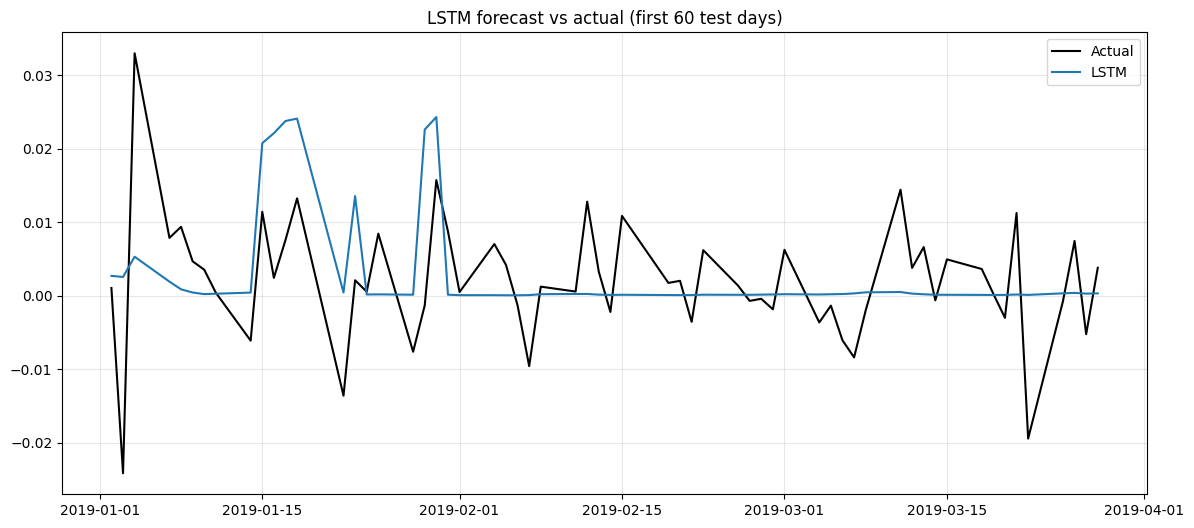

In [ ]:
# YOUR CODE HERE
y_test = test_df['log_return'].values
mae_lstm = mean_absolute_error(y_test, lstm_preds)
mae_zero = mean_absolute_error(y_test, np.zeros_like(y_test))       # MAE of predicting all zeros
print(f'LSTM MAE:        {mae_lstm:.6f}')
print(f'All-zeros MAE:   {mae_zero:.6f}')

n = 60
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(test_df.index[:n], y_test[:n], color='black', label='Actual')
ax.plot(test_df.index[:n], lstm_preds[:n], label='LSTM')
ax.set_title('LSTM forecast vs actual (first 60 test days)'); ax.legend(); plt.show()

### Exercise 5.2 — Short Answer

1. Why must the `StandardScaler` be fit on the **training set only**? What specifically leaks if you fit it on the full series?
2. The LSTM's MAE is probably *very close* to the all-zeros baseline. Is the model broken — or is that expected for daily returns? Explain.
3. The project (gotcha #3 in the plan) warns that retraining an LSTM from scratch at every backtest fold is slow. Name one way to make walk-forward backtesting with an LSTM cheaper.

**Your answers:**

1. Fitting the StandardScaler on the training set only is done to prevent data leakage. Fitting on the full series leaks the future test-period mean and standard deviation into training.

2. No, the model is not broken. Daily returns are close to a random walk and have very low predictability, so performance being close to the all-zeros baseline is expected.

3. we can use warm-start / incremental training: what it does is it carry forwards the weights from the previous fold instead of retraining the LSTM from scratch for every backtest fold.

### Exercise 5.3 — Package as a `SequenceAgent`

Collect everything above into a single class with the project's standard interface. The skeleton is given — move your scaler/training/prediction logic into the methods. This is the agent the final pipeline will import.

In [ ]:
# YOUR CODE HERE — fill fit() and predict() using your code from Sections 3-5
class SequenceAgent:
    """LSTM agent over raw return windows. Same fit/predict interface as the others."""

    def __init__(self, window_size=30, hidden=64, epochs=20, batch_size=64, lr=1e-3, patience=5):
        self.window_size = window_size; self.hidden = hidden; self.epochs = epochs
        self.batch_size = batch_size; self.lr = lr; self.patience = patience
        self._scaler = StandardScaler(); self._net = None; self._train_tail = None
        self._device = device

    @property
    def name(self): return 'SequenceAgent'

    def fit(self, train_df):
        torch.manual_seed(0); np.random.seed(0)
        # ... your normalisation + windowing + training loop here ...
        train_returns = train_df['log_return'].values.reshape(-1, 1)
        scaled_train = self._scaler.fit_transform(train_returns).flatten()

        self._train_tail = train_df['log_return'].values[-self.window_size:]

        X_np, y_np = make_sequences(scaled_train, self.window_size)
        X_t = torch.tensor(X_np).unsqueeze(-1).to(self._device)
        y_t = torch.tensor(y_np).to(self._device)

        val_n = max(1, int(0.1 * len(X_t)))
        X_tr, X_val = X_t[:-val_n], X_t[-val_n:]
        y_tr, y_val = y_t[:-val_n], y_t[-val_n:]

        loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=self.batch_size, shuffle=False)

        self._net = LSTMNet(hidden=self.hidden).to(self._device)
        optimizer = torch.optim.Adam(self._net.parameters(), lr=self.lr)
        criterion = nn.MSELoss()

        best_val, wait, best_state = float('inf'), 0, None

        for epoch in range(self.epochs):
            self._net.train()
            for xb, yb in loader:
                optimizer.zero_grad()
                loss = criterion(self._net(xb), yb)
                loss.backward()
                optimizer.step()

            self._net.eval()
            with torch.no_grad():
                val_loss = criterion(self._net(X_val), y_val).item()

            if val_loss < best_val - 1e-6:
                best_val, wait = val_loss, 0
                best_state = {k: v.clone() for k, v in self._net.state_dict().items()}

            else:
                wait += 1
                if wait >= self.patience:
                    break
        if best_state: self._net.load_state_dict(best_state)

    def predict(self, test_df):

          # ... your prepend-tail + scale + window + net + inverse_transform here ...

      test_returns = test_df['log_return'].values
      full = np.concatenate([self._train_tail, test_returns])
      scaled_full = self._scaler.transform(full.reshape(-1, 1)).flatten()

      Xte, _ = make_sequences(scaled_full, self.window_size)
      Xte_t = torch.tensor(Xte).unsqueeze(-1).to(self._device)

      self._net.eval()
      with torch.no_grad():
          preds_scaled = self._net(Xte_t).cpu().numpy()
      lstm_preds = self._scaler.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()

      return lstm_preds

print('Fill in SequenceAgent, then test: agent = SequenceAgent(epochs=10); agent.fit(train_df); agent.predict(test_df)')

Fill in SequenceAgent, then test: agent = SequenceAgent(epochs=10); agent.fit(train_df); agent.predict(test_df)


In [ ]:
agent = SequenceAgent(epochs=10)

agent.fit(train_df)

preds = agent.predict(test_df)

print(preds.shape)
print(preds[:5])

(252,)
[0.00268706 0.00253659 0.00529015 0.00190092 0.00085856]


---
## Bonus Challenge ⭐

- **A.** Change `window_size` to 10 and to 60. Does a longer memory help or hurt the 2019 MAE?
- **B.** Add a second feature to each timestep (e.g. the VIX level alongside the return) so `input_size=2`. You'll need to stack two scaled columns into each window.
- **C.** Plot the training vs validation loss per epoch. Can you *see* the point where early stopping kicked in?

In [ ]:
# BONUS — YOUR CODE HERE


---
## Submission Checklist

- [ ] `make_sequences` passes the tiny sanity check
- [ ] The LSTM trains and early stopping triggers (or runs all 20 epochs)
- [ ] You produced an LSTM MAE on 2019 and compared it to the all-zeros baseline
- [ ] `SequenceAgent.fit` / `predict` are filled in and run end-to-end
- [ ] All short-answer cells are filled in
- [ ] The notebook runs top-to-bottom with **Runtime → Restart and run all**
- [ ] Your name and date are filled in at the top

**Submit as:** `Week3_3_Sequence_Agent_LSTM_YourName.ipynb`

> **End of Week 3.** You now have four diverse agents. Next week: the **referee** that blends them, a proper **backtest**, and the **final product**.